# 20. Stable Diffusion Difference and Error Maps

This notebook generates spatial error-map diagnostics for the Stable Diffusion Inpainting baseline on the controlled 50-painting subset.

The notebook compares:

- clean reference vs damaged input,
- clean reference vs Stable Diffusion restored output,
- damaged error vs restored error,
- signed restoration improvement.

The goal is to localize where Stable Diffusion improves the damaged image, where it fails, and where it may introduce new visual errors.

## Diagnostic design

For each selected case, the diagnostic figure shows:

- clean reference,
- damage mask,
- damaged input,
- Stable Diffusion restored output,
- clean-vs-damaged absolute error,
- clean-vs-restored absolute error,
- signed improvement map,
- masked signed improvement map.

Positive signed improvement means the restored output is closer to the clean reference than the damaged input.

Negative signed improvement means the restored output is farther from the clean reference than the damaged input.

These maps are especially important for generative inpainting because a visually plausible output can still be spatially inconsistent with the known clean target.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import yaml
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.error_maps import (
    generate_error_map_figures_for_cases,
    validate_error_map_manifest,
)

print("Project root:", PROJECT_ROOT)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

restored_metadata_path = processed_metadata_dir / "metadata_restored_stable_diffusion.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"
classical_metrics_path = metrics_dir / "classical_metrics_stable_diffusion_50.csv"

error_map_manifest_path = metrics_dir / "error_map_manifest_stable_diffusion_50.csv"
error_map_summary_by_mask_type_path = metrics_dir / "error_map_summary_by_mask_type_stable_diffusion_50.csv"
error_map_summary_by_category_path = metrics_dir / "error_map_summary_by_category_stable_diffusion_50.csv"
error_map_visual_cases_path = metrics_dir / "stable_diffusion_error_map_visual_cases_50.csv"

error_map_figures_dir = figures_dir / "error_maps" / "stable_diffusion_inpainting"
error_map_figures_dir.mkdir(parents=True, exist_ok=True)

model_name = "stable_diffusion_inpainting"

print("Restored metadata:", restored_metadata_path)
print("Processed clean metadata:", processed_clean_metadata_path)
print("Classical metrics:", classical_metrics_path)
print("Error-map manifest output:", error_map_manifest_path)
print("Error-map figures dir:", error_map_figures_dir)

Restored metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_stable_diffusion.csv
Processed clean metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Classical metrics: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\classical_metrics_stable_diffusion_50.csv
Error-map manifest output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\error_map_manifest_stable_diffusion_50.csv
Error-map figures dir: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\stable_diffusion_inpainting


In [3]:
if not restored_metadata_path.exists():
    raise FileNotFoundError(f"Stable Diffusion restored metadata not found: {restored_metadata_path}")

if not processed_clean_metadata_path.exists():
    raise FileNotFoundError(f"Processed clean metadata not found: {processed_clean_metadata_path}")

if not classical_metrics_path.exists():
    raise FileNotFoundError(f"Stable Diffusion classical metrics not found: {classical_metrics_path}")

restored_df = pd.read_csv(restored_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)
classical_metrics_df = pd.read_csv(classical_metrics_path)

print("Restored metadata shape:", restored_df.shape)
print("Processed clean metadata shape:", processed_clean_df.shape)
print("Classical metrics shape:", classical_metrics_df.shape)

display(restored_df.head())
display(classical_metrics_df.head())

Restored metadata shape: (250, 36)
Processed clean metadata shape: (50, 43)
Classical metrics shape: (900, 30)


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,...,negative_prompt,seed,num_inference_steps,guidance_scale,inference_size,device,case_runtime_seconds,restored_width,restored_height,restored_mode
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,cuda,6.554261,768,768,RGB
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,cuda,6.619525,768,768,RGB
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,cuda,6.606830,768,768,RGB
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,cuda,6.153014,768,768,RGB
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,"modern objects, text, watermark, signature, fr...",2026,30,7.5,512,none,0.000000,768,768,RGB


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement,damaged_ssim,restored_ssim,ssim_improvement,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,full_image,589824,0.0,...,6.236044,18.822454,10.659855,26.741063,16.081208,0.897178,0.816961,-0.080217,ok,NaN
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,content_region,509184,52.0,...,6.727410,22.299629,10.021378,26.158902,16.137525,0.880745,0.794350,-0.086395,ok,NaN
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,masked_region,67242,NaN,...,19.113932,200.690710,1.229037,18.761777,17.532740,NaN,NaN,NaN,ok,NaN
3,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,mask_bbox_crop,126750,221.0,...,12.929867,103.678425,3.982111,21.182676,17.200564,0.512661,0.631288,0.118627,ok,NaN
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,stable_diffusion_inpainting,full_image,589824,0.0,...,3.940423,4.923999,15.279670,31.984701,16.705031,0.953800,0.852229,-0.101571,ok,NaN


In [4]:
metadata_columns = [
    "painting_id",
    "category",
    "title",
]

missing_metadata_columns = [
    column for column in metadata_columns
    if column not in processed_clean_df.columns
]

if missing_metadata_columns:
    raise ValueError(
        f"Processed clean metadata missing columns: {missing_metadata_columns}"
    )

columns_to_drop_before_merge = [
    column
    for column in ["category", "title"]
    if column in restored_df.columns
]

stable_diffusion_cases_df = restored_df.drop(
    columns=columns_to_drop_before_merge
).merge(
    processed_clean_df[metadata_columns],
    on="painting_id",
    how="left",
    validate="many_to_one",
)

print("Stable Diffusion cases shape:", stable_diffusion_cases_df.shape)

display(
    stable_diffusion_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "model_name",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ].head()
)

Stable Diffusion cases shape: (250, 38)


,case_id,painting_id,category,title,mask_type,model_name,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,zero_control,stable_diffusion_inpainting,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,data/processed/restored/stable_diffusion_inpai...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [5]:
required_case_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "status",
]

missing_case_columns = [
    column for column in required_case_columns
    if column not in stable_diffusion_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"Stable Diffusion cases missing columns: {missing_case_columns}")

if len(stable_diffusion_cases_df) != 250:
    raise ValueError(
        f"Expected 250 Stable Diffusion restoration rows, found {len(stable_diffusion_cases_df)}."
    )

if (stable_diffusion_cases_df["status"] != "ok").any():
    display(stable_diffusion_cases_df[stable_diffusion_cases_df["status"] != "ok"])
    raise ValueError("Stable Diffusion metadata contains non-ok rows.")

if set(stable_diffusion_cases_df["model_name"].dropna().unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {stable_diffusion_cases_df['model_name'].unique()}"
    )

def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


stable_diffusion_cases_abs_df = stable_diffusion_cases_df.copy()

for path_column in ["clean_path", "damaged_path", "restored_path", "mask_path"]:
    stable_diffusion_cases_abs_df[path_column] = stable_diffusion_cases_abs_df[path_column].map(
        lambda value: str(resolve_project_path(value))
    )

    missing_files = [
        path
        for path in stable_diffusion_cases_abs_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files after absolute-path conversion:", len(missing_files))

    if missing_files:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_files[:10]}"
        )

print("\nStable Diffusion error-map metadata gates passed.")

clean_path missing files after absolute-path conversion: 0
damaged_path missing files after absolute-path conversion: 0
restored_path missing files after absolute-path conversion: 0
mask_path missing files after absolute-path conversion: 0

Stable Diffusion error-map metadata gates passed.


## Visual diagnostic case selection policy

Spatial diagnostics are generated from a fixed case-selection policy rather than manual cherry-picking.

The selected cases include:

- best cases by masked-region MSE improvement,
- worst cases by masked-region MSE improvement,
- median representative cases,
- metric-disagreement cases,
- one representative case per category and mask type where useful.

This selection policy is intended to show both successes and failures. It also highlights cases where different metrics disagree, which is especially important for generative inpainting models.

In [6]:
masked_metrics_df = classical_metrics_df[
    classical_metrics_df["evaluation_region"] == "masked_region"
].copy()

if len(masked_metrics_df) != 200:
    raise ValueError(
        f"Expected 200 masked-region metric rows, found {len(masked_metrics_df)}."
    )

required_masked_metric_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
]

missing_masked_metric_columns = [
    column for column in required_masked_metric_columns
    if column not in masked_metrics_df.columns
]

if missing_masked_metric_columns:
    raise ValueError(
        f"Masked-region metric table missing columns: {missing_masked_metric_columns}"
    )

print("Masked-region metric rows:", len(masked_metrics_df))

display(
    masked_metrics_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "mse_improvement",
            "mae_improvement",
            "psnr_improvement",
            "ssim_improvement",
        ]
    ].head()
)

Masked-region metric rows: 200


,case_id,painting_id,category,title,mask_type,mse_improvement,mae_improvement,psnr_improvement,ssim_improvement
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,48133.030640,200.690710,17.532740,NaN
6,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,46912.756538,210.864386,27.543226,NaN
10,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,49826.728882,208.766875,17.444243,NaN
14,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,42301.111328,155.702362,8.929056,NaN
20,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,50524.246399,207.889894,18.609613,NaN


In [7]:
best_cases_df = (
    masked_metrics_df
    .sort_values("mse_improvement", ascending=False)
    .head(10)
    .copy()
)

best_cases_df["selection_reason"] = "best_masked_region_mse_improvement"

worst_cases_df = (
    masked_metrics_df
    .sort_values("mse_improvement", ascending=True)
    .head(10)
    .copy()
)

worst_cases_df["selection_reason"] = "worst_masked_region_mse_improvement"

median_source_df = masked_metrics_df.copy()
median_mse_improvement = median_source_df["mse_improvement"].median()
median_source_df["distance_from_median_mse_improvement"] = (
    median_source_df["mse_improvement"] - median_mse_improvement
).abs()

median_cases_df = (
    median_source_df
    .sort_values("distance_from_median_mse_improvement", ascending=True)
    .head(10)
    .copy()
)

median_cases_df["selection_reason"] = "median_representative_masked_region_mse_improvement"

print("Best cases:", len(best_cases_df))
print("Worst cases:", len(worst_cases_df))
print("Median representative cases:", len(median_cases_df))

display(
    pd.concat(
        [
            best_cases_df.head(3),
            worst_cases_df.head(3),
            median_cases_df.head(3),
        ],
        ignore_index=True,
    )[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "mse_improvement",
            "psnr_improvement",
            "ssim_improvement",
        ]
    ]
)

Best cases: 10
Worst cases: 10
Median representative cases: 10


,case_id,category,mask_type,selection_reason,mse_improvement,psnr_improvement,ssim_improvement
0,p006_mixed_damage,portrait_figure,mixed_damage,best_masked_region_mse_improvement,50689.984497,16.097077,NaN
1,p002_loss_large,portrait_figure,loss_large,best_masked_region_mse_improvement,50524.246399,18.609613,NaN
2,p001_mixed_damage,portrait_figure,mixed_damage,best_masked_region_mse_improvement,49826.728882,17.444243,NaN
3,p036_scratch_thin,abstraction_surrealism,scratch_thin,worst_masked_region_mse_improvement,-7839.791138,-6.902404,NaN
4,p036_loss_large,abstraction_surrealism,loss_large,worst_masked_region_mse_improvement,-1520.606445,-1.102267,NaN
5,p032_scratch_thin,abstraction_surrealism,scratch_thin,worst_masked_region_mse_improvement,-136.981445,-0.099862,NaN
6,p041_scratch_thin,high_texture_brushwork,scratch_thin,median_representative_masked_region_mse_improv...,24521.362549,10.948645,NaN
7,p044_mixed_damage,high_texture_brushwork,mixed_damage,median_representative_masked_region_mse_improv...,24533.028992,14.393879,NaN
8,p029_loss_large,architecture_structured,loss_large,median_representative_masked_region_mse_improv...,24481.545532,14.128107,NaN


In [8]:
metric_disagreement_df = masked_metrics_df.copy()

metric_disagreement_df["mse_improved"] = metric_disagreement_df["mse_improvement"] > 0
metric_disagreement_df["mae_improved"] = metric_disagreement_df["mae_improvement"] > 0
metric_disagreement_df["psnr_improved"] = metric_disagreement_df["psnr_improvement"] > 0
metric_disagreement_df["ssim_improved"] = metric_disagreement_df["ssim_improvement"] > 0

improvement_vote_columns = [
    "mse_improved",
    "mae_improved",
    "psnr_improved",
    "ssim_improved",
]

metric_disagreement_df["num_classical_metrics_improved"] = metric_disagreement_df[
    improvement_vote_columns
].sum(axis=1)

metric_disagreement_df["num_classical_metrics_worsened_or_tied"] = (
    len(improvement_vote_columns)
    - metric_disagreement_df["num_classical_metrics_improved"]
)

metric_disagreement_df = metric_disagreement_df[
    metric_disagreement_df["num_classical_metrics_improved"].between(1, 3)
].copy()

metric_disagreement_df["selection_reason"] = "classical_metric_disagreement"

metric_disagreement_df = (
    metric_disagreement_df
    .sort_values(
        [
            "num_classical_metrics_improved",
            "mse_improvement",
        ],
        ascending=[True, True],
    )
    .head(15)
    .copy()
)

print("Metric-disagreement cases:", len(metric_disagreement_df))

display(
    metric_disagreement_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "mse_improvement",
            "mae_improvement",
            "psnr_improvement",
            "ssim_improvement",
            "num_classical_metrics_improved",
            "num_classical_metrics_worsened_or_tied",
        ]
    ]
)

Metric-disagreement cases: 15


,case_id,category,mask_type,selection_reason,mse_improvement,mae_improvement,psnr_improvement,ssim_improvement,num_classical_metrics_improved,num_classical_metrics_worsened_or_tied
632,p036_loss_large,abstraction_surrealism,loss_large,classical_metric_disagreement,-1520.606445,6.680202,-1.102267,NaN,1,3
568,p032_mixed_damage,abstraction_surrealism,mixed_damage,classical_metric_disagreement,1885.202820,25.115807,4.977558,NaN,3,1
640,p036_mixed_damage,abstraction_surrealism,mixed_damage,classical_metric_disagreement,2743.432495,21.039778,3.804026,NaN,3,1
636,p036_loss_small,abstraction_surrealism,loss_small,classical_metric_disagreement,3229.334770,29.911582,17.276791,NaN,3,1
344,p020_loss_large,landscape_natural,loss_large,classical_metric_disagreement,3271.845215,27.701603,3.080567,NaN,3,1
348,p020_loss_small,landscape_natural,loss_small,classical_metric_disagreement,3800.551697,48.668884,9.862825,NaN,3,1
352,p020_mixed_damage,landscape_natural,mixed_damage,classical_metric_disagreement,4041.236023,42.876169,7.258836,NaN,3,1
740,p042_loss_large,high_texture_brushwork,loss_large,classical_metric_disagreement,5099.876549,64.060284,16.376445,NaN,3,1
356,p020_scratch_thin,landscape_natural,scratch_thin,classical_metric_disagreement,5508.611084,34.987225,4.063810,NaN,3,1
560,p032_loss_large,abstraction_surrealism,loss_large,classical_metric_disagreement,7215.788330,53.006189,17.233556,NaN,3,1


In [9]:
category_mask_cases_df = (
    masked_metrics_df
    .sort_values("mse_improvement", ascending=False)
    .groupby(["category", "mask_type"], dropna=False)
    .head(1)
    .copy()
)

category_mask_cases_df["selection_reason"] = "category_mask_representative_best_mse_improvement"

expected_category_mask_rows = 5 * 4

if len(category_mask_cases_df) != expected_category_mask_rows:
    raise ValueError(
        f"Expected {expected_category_mask_rows} category/mask representative rows, "
        f"found {len(category_mask_cases_df)}."
    )

print("Category/mask representative cases:", len(category_mask_cases_df))

display(
    category_mask_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "mse_improvement",
            "psnr_improvement",
            "ssim_improvement",
        ]
    ].sort_values(["category", "mask_type"])
)

Category/mask representative cases: 20


,case_id,category,mask_type,selection_reason,mse_improvement,psnr_improvement,ssim_improvement
650,p037_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_mse_improvement,32135.705566,13.917994,NaN
708,p040_loss_small,abstraction_surrealism,loss_small,category_mask_representative_best_mse_improvement,28398.119507,13.759976,NaN
694,p039_mixed_damage,abstraction_surrealism,mixed_damage,category_mask_representative_best_mse_improvement,30366.616455,13.087982,NaN
716,p040_scratch_thin,abstraction_surrealism,scratch_thin,category_mask_representative_best_mse_improvement,26005.687988,9.614419,NaN
524,p030_loss_large,architecture_structured,loss_large,category_mask_representative_best_mse_improvement,29672.559326,14.051405,NaN
384,p022_loss_small,architecture_structured,loss_small,category_mask_representative_best_mse_improvement,36293.687012,15.397236,NaN
424,p024_mixed_damage,architecture_structured,mixed_damage,category_mask_representative_best_mse_improvement,35881.376221,16.918928,NaN
428,p024_scratch_thin,architecture_structured,scratch_thin,category_mask_representative_best_mse_improvement,33975.858521,13.442452,NaN
884,p050_loss_large,high_texture_brushwork,loss_large,category_mask_representative_best_mse_improvement,35462.074097,13.798416,NaN
888,p050_loss_small,high_texture_brushwork,loss_small,category_mask_representative_best_mse_improvement,34283.761597,18.107177,NaN


In [10]:
visual_selection_raw_df = pd.concat(
    [
        best_cases_df,
        worst_cases_df,
        median_cases_df,
        metric_disagreement_df,
        category_mask_cases_df,
    ],
    ignore_index=True,
)

selection_reason_df = (
    visual_selection_raw_df
    .groupby("case_id", dropna=False)
    .agg(
        selection_reason=(
            "selection_reason",
            lambda values: "; ".join(sorted(set(values))),
        )
    )
    .reset_index()
)

visual_selection_base_columns = [
    column for column in visual_selection_raw_df.columns
    if column != "selection_reason"
]

visual_cases_df = (
    visual_selection_raw_df[visual_selection_base_columns]
    .drop_duplicates(subset=["case_id"])
    .merge(selection_reason_df, on="case_id", how="left", validate="one_to_one")
    .sort_values(["category", "mask_type", "case_id"])
    .reset_index(drop=True)
)

print("Raw selected rows:", len(visual_selection_raw_df))
print("Unique selected diagnostic cases:", len(visual_cases_df))

display(
    visual_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "selection_reason",
            "mse_improvement",
            "mae_improvement",
            "psnr_improvement",
            "ssim_improvement",
        ]
    ]
)

Raw selected rows: 65
Unique selected diagnostic cases: 53


,case_id,painting_id,category,title,mask_type,selection_reason,mse_improvement,mae_improvement,psnr_improvement,ssim_improvement
0,p032_loss_large,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_large,classical_metric_disagreement,7215.788330,53.006189,17.233556,NaN
1,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_large,classical_metric_disagreement; worst_masked_re...,-1520.606445,6.680202,-1.102267,NaN
2,p037_loss_large,p037,abstraction_surrealism,In the Sea,loss_large,category_mask_representative_best_mse_improvement,32135.705566,154.371624,13.917994,NaN
3,p032_loss_small,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_small,classical_metric_disagreement,8251.094635,60.599907,19.263480,NaN
4,p035_loss_small,p035,abstraction_surrealism,The Bewitched Mill,loss_small,median_representative_masked_region_mse_improv...,24212.374268,123.625906,12.690334,NaN
5,p036_loss_small,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_small,classical_metric_disagreement; worst_masked_re...,3229.334770,29.911582,17.276791,NaN
6,p040_loss_small,p040,abstraction_surrealism,Houses at Murnau,loss_small,category_mask_representative_best_mse_improvement,28398.119507,137.887709,13.759976,NaN
7,p032_mixed_damage,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,mixed_damage,classical_metric_disagreement; worst_masked_re...,1885.202820,25.115807,4.977558,NaN
8,p036_mixed_damage,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",mixed_damage,classical_metric_disagreement; worst_masked_re...,2743.432495,21.039778,3.804026,NaN
9,p039_mixed_damage,p039,abstraction_surrealism,Painting with Troika,mixed_damage,category_mask_representative_best_mse_improvement,30366.616455,146.053001,13.087982,NaN


In [11]:
path_lookup_columns = [
    "case_id",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

path_lookup_df = stable_diffusion_cases_abs_df[path_lookup_columns].copy()

existing_path_columns = [
    column
    for column in ["clean_path", "damaged_path", "restored_path", "mask_path"]
    if column in visual_cases_df.columns
]

visual_cases_df = visual_cases_df.drop(columns=existing_path_columns).merge(
    path_lookup_df,
    on="case_id",
    how="left",
    validate="one_to_one",
)

required_visual_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_path_values = visual_cases_df[required_visual_path_columns].isna().sum()

print("Missing merged path values:")
display(missing_path_values)

for path_column in required_visual_path_columns:
    if visual_cases_df[path_column].isna().any():
        raise ValueError(f"Missing merged values in {path_column!r}.")

    missing_files = [
        path
        for path in visual_cases_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files:", len(missing_files))

    if missing_files:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_files[:10]}"
        )

print("Selected diagnostic cases now include valid image paths.")

display(
    visual_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ].head()
)

Missing merged path values:


clean_path       0
damaged_path     0
restored_path    0
mask_path        0
dtype: int64

clean_path missing files: 0
damaged_path missing files: 0
restored_path missing files: 0
mask_path missing files: 0
Selected diagnostic cases now include valid image paths.


,case_id,category,mask_type,selection_reason,clean_path,damaged_path,restored_path,mask_path
0,p032_loss_large,abstraction_surrealism,loss_large,classical_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p036_loss_large,abstraction_surrealism,loss_large,classical_metric_disagreement; worst_masked_re...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p037_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_mse_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p032_loss_small,abstraction_surrealism,loss_small,classical_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p035_loss_small,abstraction_surrealism,loss_small,median_representative_masked_region_mse_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [12]:
visual_cases_df.to_csv(error_map_visual_cases_path, index=False)

if not error_map_visual_cases_path.exists():
    raise FileNotFoundError(
        f"Visual diagnostic case file was not saved: {error_map_visual_cases_path}"
    )

saved_visual_cases_df = pd.read_csv(error_map_visual_cases_path)

if len(saved_visual_cases_df) != len(visual_cases_df):
    raise ValueError(
        f"Saved visual cases row mismatch: expected {len(visual_cases_df)}, "
        f"found {len(saved_visual_cases_df)}."
    )

print("Saved Stable Diffusion error-map visual cases:")
print(error_map_visual_cases_path)
print("Rows:", len(saved_visual_cases_df))

Saved Stable Diffusion error-map visual cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_error_map_visual_cases_50.csv
Rows: 53


In [14]:
error_map_manifest_df = generate_error_map_figures_for_cases(
    visual_cases_df,
    output_dir=error_map_figures_dir,
    progress_every=5,
)

print("Generated Stable Diffusion error-map manifest shape:", error_map_manifest_df.shape)

display(error_map_manifest_df.head())

error_map_manifest_df.to_csv(error_map_manifest_path, index=False)

if not error_map_manifest_path.exists():
    raise FileNotFoundError(
        f"Error-map manifest file was not saved: {error_map_manifest_path}"
    )

print("Saved Stable Diffusion error-map manifest:")
print(error_map_manifest_path)

Starting error-map generation for 53 cases...
Output directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\error_maps\stable_diffusion_inpainting
Processed 1/53 cases...
Processed 5/53 cases...
Processed 10/53 cases...
Processed 15/53 cases...
Processed 20/53 cases...
Processed 25/53 cases...
Processed 30/53 cases...
Processed 35/53 cases...
Processed 40/53 cases...
Processed 45/53 cases...
Processed 50/53 cases...
Processed 53/53 cases...
Error-map generation finished.
Generated Stable Diffusion error-map manifest shape: (53, 29)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,selection_group,figure_filename,figure_path,...,damaged_error_mean_masked,restored_error_mean_masked,improvement_mean_masked,negative_improvement_pixels_masked,positive_improvement_pixels_masked,zero_improvement_pixels_masked,negative_improvement_percentage_masked,positive_improvement_percentage_masked,status,issue
0,p032_loss_large,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,p032_loss_large,loss_large,stable_diffusion_inpainting,,p032_loss_large_stable_diffusion_inpainting_er...,D:\Masters\FH\Thesis\painting-restoration-eval...,...,61.183594,8.177400,53.006187,1025,87028,36,1.163596,98.795536,ok,
1,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",p036_loss_large,loss_large,stable_diffusion_inpainting,,p036_loss_large_stable_diffusion_inpainting_er...,D:\Masters\FH\Thesis\painting-restoration-eval...,...,46.358219,39.678013,6.680202,15521,76630,23,16.838805,83.136242,ok,
2,p037_loss_large,p037,abstraction_surrealism,In the Sea,p037_loss_large,loss_large,stable_diffusion_inpainting,,p037_loss_large_stable_diffusion_inpainting_er...,D:\Masters\FH\Thesis\painting-restoration-eval...,...,177.572388,23.200796,154.371597,17,47197,2,0.036005,99.959759,ok,
3,p032_loss_small,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,p032_loss_small,loss_small,stable_diffusion_inpainting,,p032_loss_small_stable_diffusion_inpainting_er...,D:\Masters\FH\Thesis\painting-restoration-eval...,...,67.464615,6.864707,60.599911,202,24153,7,0.829160,99.142107,ok,
4,p035_loss_small,p035,abstraction_surrealism,The Bewitched Mill,p035_loss_small,loss_small,stable_diffusion_inpainting,,p035_loss_small_stable_diffusion_inpainting_er...,D:\Masters\FH\Thesis\painting-restoration-eval...,...,147.608002,23.982096,123.625900,120,13468,3,0.882937,99.094989,ok,


Saved Stable Diffusion error-map manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\error_map_manifest_stable_diffusion_50.csv


In [16]:
error_map_validation_df = validate_error_map_manifest(
    error_map_manifest_df,
    expected_rows=len(visual_cases_df),
)

print("Validation output columns:")
print(list(error_map_validation_df.columns))

display(error_map_validation_df)

# Robust validation handling because helper output schema may differ.
if "status" in error_map_validation_df.columns:
    if (error_map_validation_df["status"] != "ok").any():
        display(error_map_validation_df[error_map_validation_df["status"] != "ok"])
        raise ValueError("Stable Diffusion error-map manifest validation failed.")

elif "passed" in error_map_validation_df.columns:
    if (~error_map_validation_df["passed"].astype(bool)).any():
        display(error_map_validation_df[~error_map_validation_df["passed"].astype(bool)])
        raise ValueError("Stable Diffusion error-map manifest validation failed.")

elif "is_valid" in error_map_validation_df.columns:
    if (~error_map_validation_df["is_valid"].astype(bool)).any():
        display(error_map_validation_df[~error_map_validation_df["is_valid"].astype(bool)])
        raise ValueError("Stable Diffusion error-map manifest validation failed.")

else:
    print(
        "No standard validation status column found. "
        "Proceeding with explicit manifest/file checks below."
    )

saved_error_map_manifest_df = pd.read_csv(error_map_manifest_path)

if len(saved_error_map_manifest_df) != len(visual_cases_df):
    raise ValueError(
        f"Saved error-map manifest row mismatch: expected {len(visual_cases_df)}, "
        f"found {len(saved_error_map_manifest_df)}."
    )

required_manifest_columns = [
    "case_id",
    "painting_id",
    "category",
    "mask_type",
]

missing_manifest_columns = [
    column for column in required_manifest_columns
    if column not in saved_error_map_manifest_df.columns
]

if missing_manifest_columns:
    raise ValueError(
        f"Saved error-map manifest missing required columns: {missing_manifest_columns}"
    )

figure_path_columns = [
    column
    for column in saved_error_map_manifest_df.columns
    if "figure" in column.lower() and "path" in column.lower()
]

print("Figure path columns:", figure_path_columns)

if not figure_path_columns:
    print("Manifest columns:")
    print(list(saved_error_map_manifest_df.columns))
    raise ValueError("Could not identify figure path columns in error-map manifest.")

for figure_path_column in figure_path_columns:
    missing_figures = [
        path
        for path in saved_error_map_manifest_df[figure_path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(figure_path_column, "missing figures:", len(missing_figures))

    if missing_figures:
        raise FileNotFoundError(
            f"Missing figures in {figure_path_column!r}: {missing_figures[:10]}"
        )

print("Saved error-map manifest rows:", len(saved_error_map_manifest_df))
print("Stable Diffusion error-map manifest validation passed.")

Validation output columns:
['check', 'passed', 'detail']


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 53, found 53."
2,status_ok,True,Rows with non-ok status: 0.
3,figures_exist,True,Missing figure files: 0.


Figure path columns: ['figure_path']
figure_path missing figures: 0
Saved error-map manifest rows: 53
Stable Diffusion error-map manifest validation passed.


In [17]:
error_map_manifest_saved_df = pd.read_csv(error_map_manifest_path)
error_map_visual_cases_saved_df = pd.read_csv(error_map_visual_cases_path)

summary_by_mask_type_df = (
    error_map_visual_cases_saved_df
    .groupby("mask_type", dropna=False)
    .agg(
        selected_cases=("case_id", "count"),
        mean_mse_improvement=("mse_improvement", "mean"),
        median_mse_improvement=("mse_improvement", "median"),
        mean_psnr_improvement=("psnr_improvement", "mean"),
        median_psnr_improvement=("psnr_improvement", "median"),
        mean_ssim_improvement=("ssim_improvement", "mean"),
        median_ssim_improvement=("ssim_improvement", "median"),
    )
    .reset_index()
    .sort_values("mask_type")
)

summary_by_category_df = (
    error_map_visual_cases_saved_df
    .groupby("category", dropna=False)
    .agg(
        selected_cases=("case_id", "count"),
        mean_mse_improvement=("mse_improvement", "mean"),
        median_mse_improvement=("mse_improvement", "median"),
        mean_psnr_improvement=("psnr_improvement", "mean"),
        median_psnr_improvement=("psnr_improvement", "median"),
        mean_ssim_improvement=("ssim_improvement", "mean"),
        median_ssim_improvement=("ssim_improvement", "median"),
    )
    .reset_index()
    .sort_values("category")
)

summary_by_mask_type_df.to_csv(error_map_summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(error_map_summary_by_category_path, index=False)

print("Saved Stable Diffusion error-map summary by mask type:")
print(error_map_summary_by_mask_type_path)
display(summary_by_mask_type_df)

print("\nSaved Stable Diffusion error-map summary by category:")
print(error_map_summary_by_category_path)
display(summary_by_category_df)

Saved Stable Diffusion error-map summary by mask type:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\error_map_summary_by_mask_type_stable_diffusion_50.csv


,mask_type,selected_cases,mean_mse_improvement,median_mse_improvement,mean_psnr_improvement,median_psnr_improvement,mean_ssim_improvement,median_ssim_improvement
0,loss_large,13,25828.537055,29672.559326,12.443215,14.051405,NaN,NaN
1,loss_small,14,27330.526296,26402.211090,17.804902,16.856326,NaN,NaN
2,mixed_damage,15,25595.716581,24390.736206,12.203970,13.359441,NaN,NaN
3,scratch_thin,11,23472.816184,26005.687988,7.256318,9.614419,NaN,NaN



Saved Stable Diffusion error-map summary by category:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\error_map_summary_by_category_stable_diffusion_50.csv


,category,selected_cases,mean_mse_improvement,median_mse_improvement,mean_psnr_improvement,median_psnr_improvement,mean_ssim_improvement,median_ssim_improvement
0,abstraction_surrealism,13,11918.921370,7215.788330,9.040122,12.690334,NaN,NaN
1,architecture_structured,7,29767.499826,29672.559326,14.681327,14.128107,NaN,NaN
2,high_texture_brushwork,9,27563.847232,24533.028992,14.238744,14.393879,NaN,NaN
3,landscape_natural,13,18823.971609,8670.136963,9.831832,8.126471,NaN,NaN
4,portrait_figure,11,45857.304001,47805.209961,17.968735,17.444243,NaN,NaN


Displaying sample Stable Diffusion error-map figures: 7


,case_id,category,mask_type,selection_reason,figure_path
42,p001_loss_large,portrait_figure,loss_large,best_masked_region_mse_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
43,p002_loss_large,portrait_figure,loss_large,best_masked_region_mse_improvement; category_m...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p037_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_mse_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
0,p032_loss_large,abstraction_surrealism,loss_large,classical_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p036_loss_large,abstraction_surrealism,loss_large,classical_metric_disagreement; worst_masked_re...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p035_loss_small,abstraction_surrealism,loss_small,median_representative_masked_region_mse_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
10,p032_scratch_thin,abstraction_surrealism,scratch_thin,worst_masked_region_mse_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying p001_loss_large | portrait_figure | loss_large | best_masked_region_mse_improvement


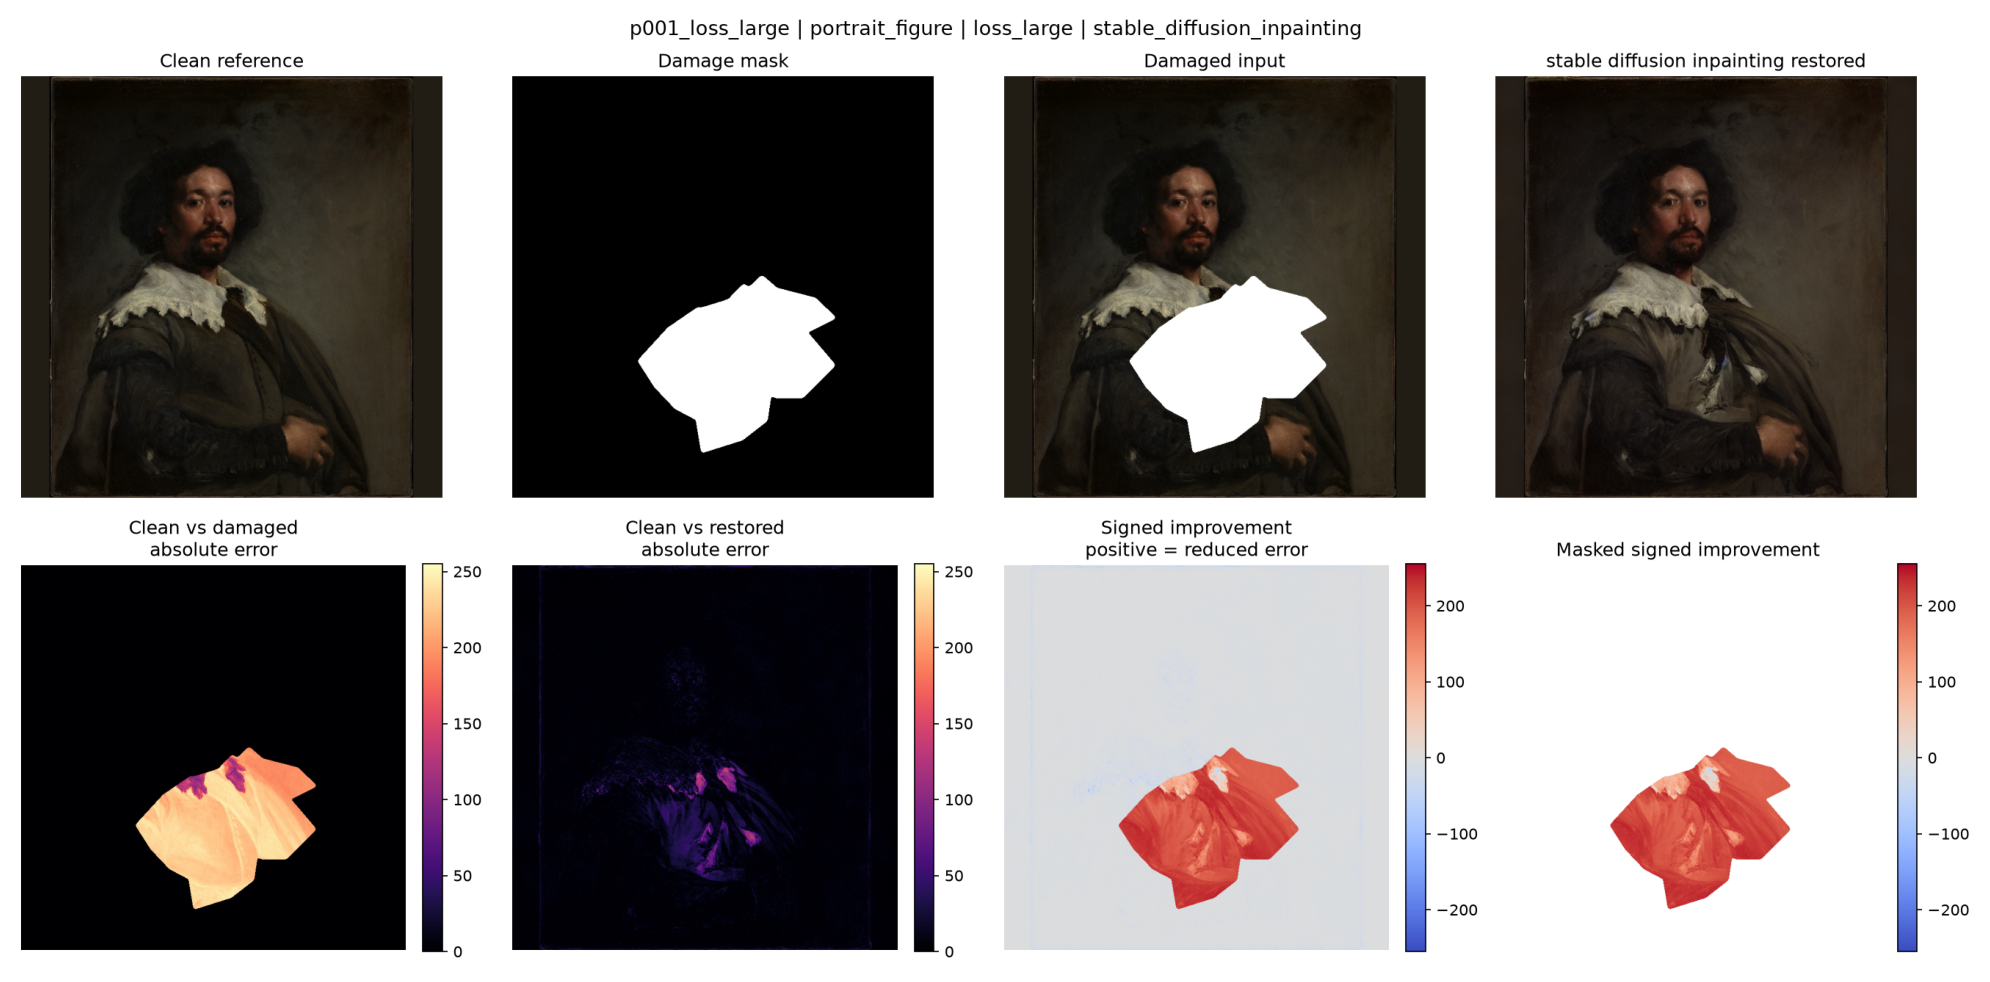

Displaying p002_loss_large | portrait_figure | loss_large | best_masked_region_mse_improvement; category_mask_representative_best_mse_improvement


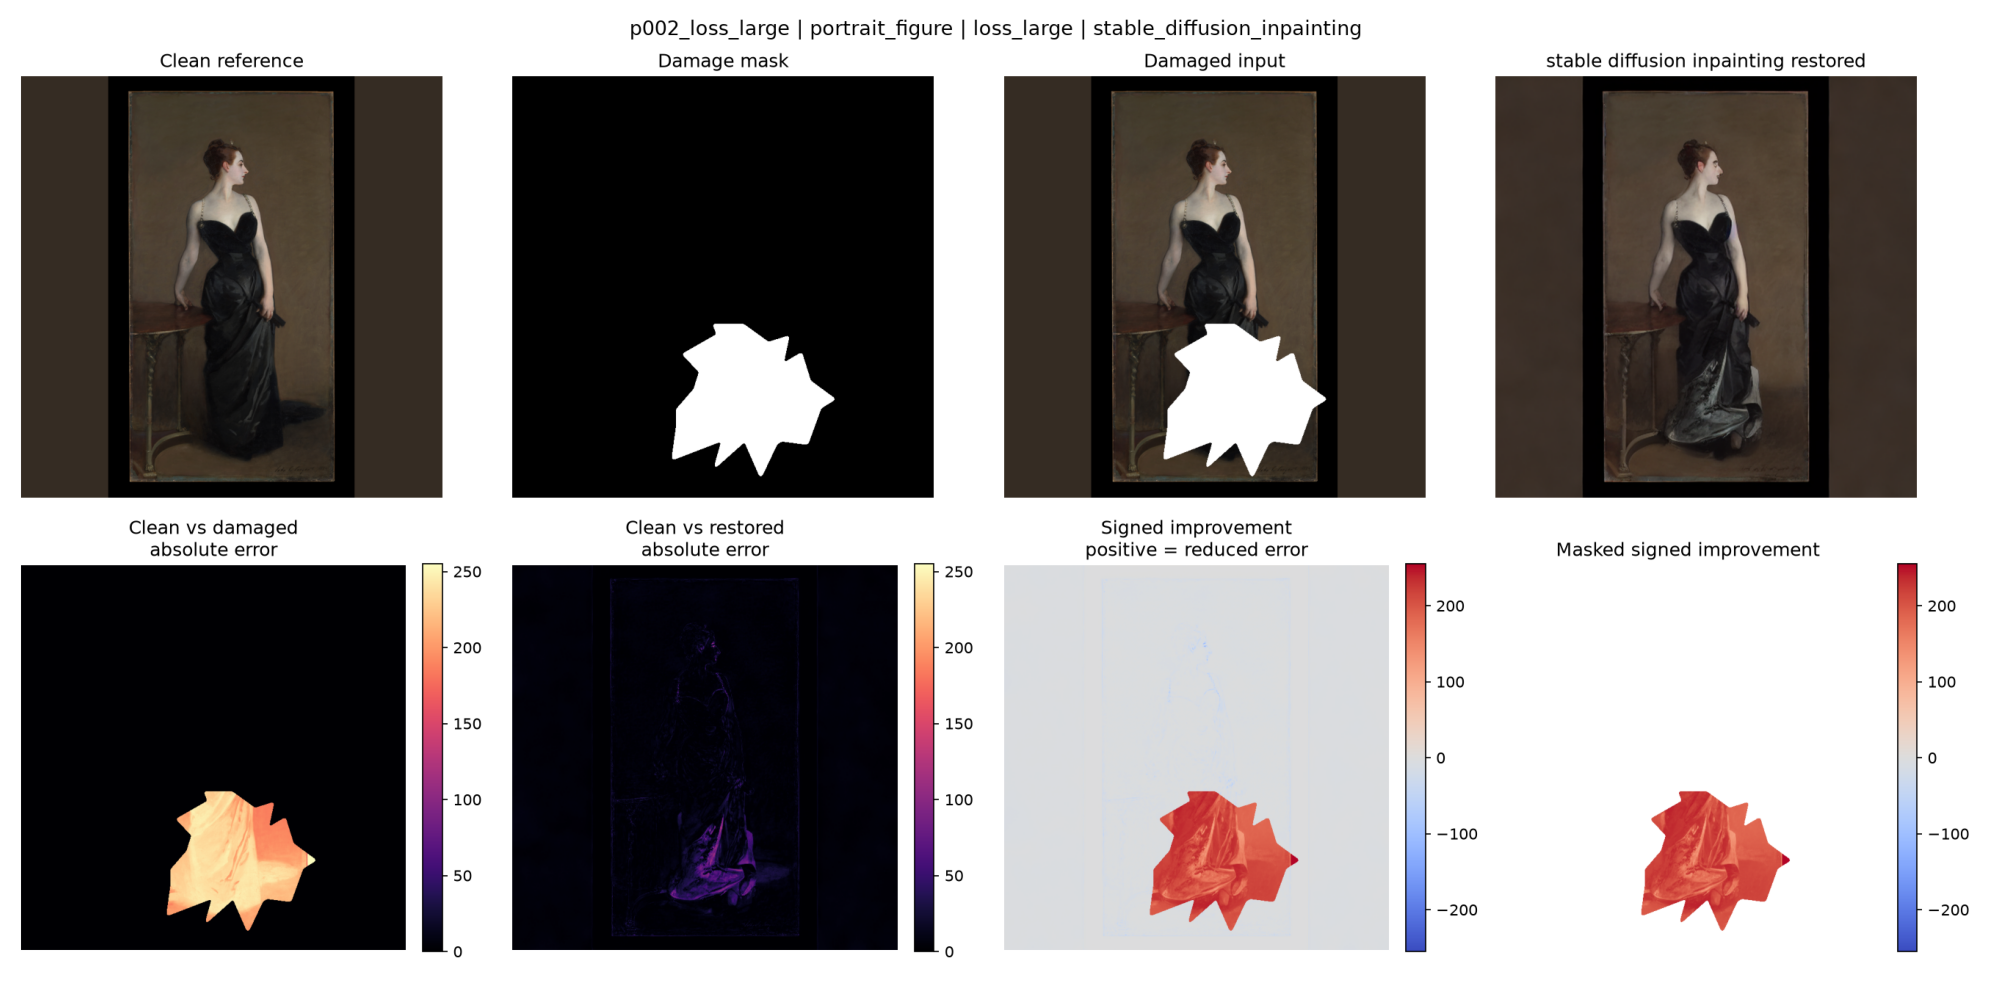

Displaying p037_loss_large | abstraction_surrealism | loss_large | category_mask_representative_best_mse_improvement


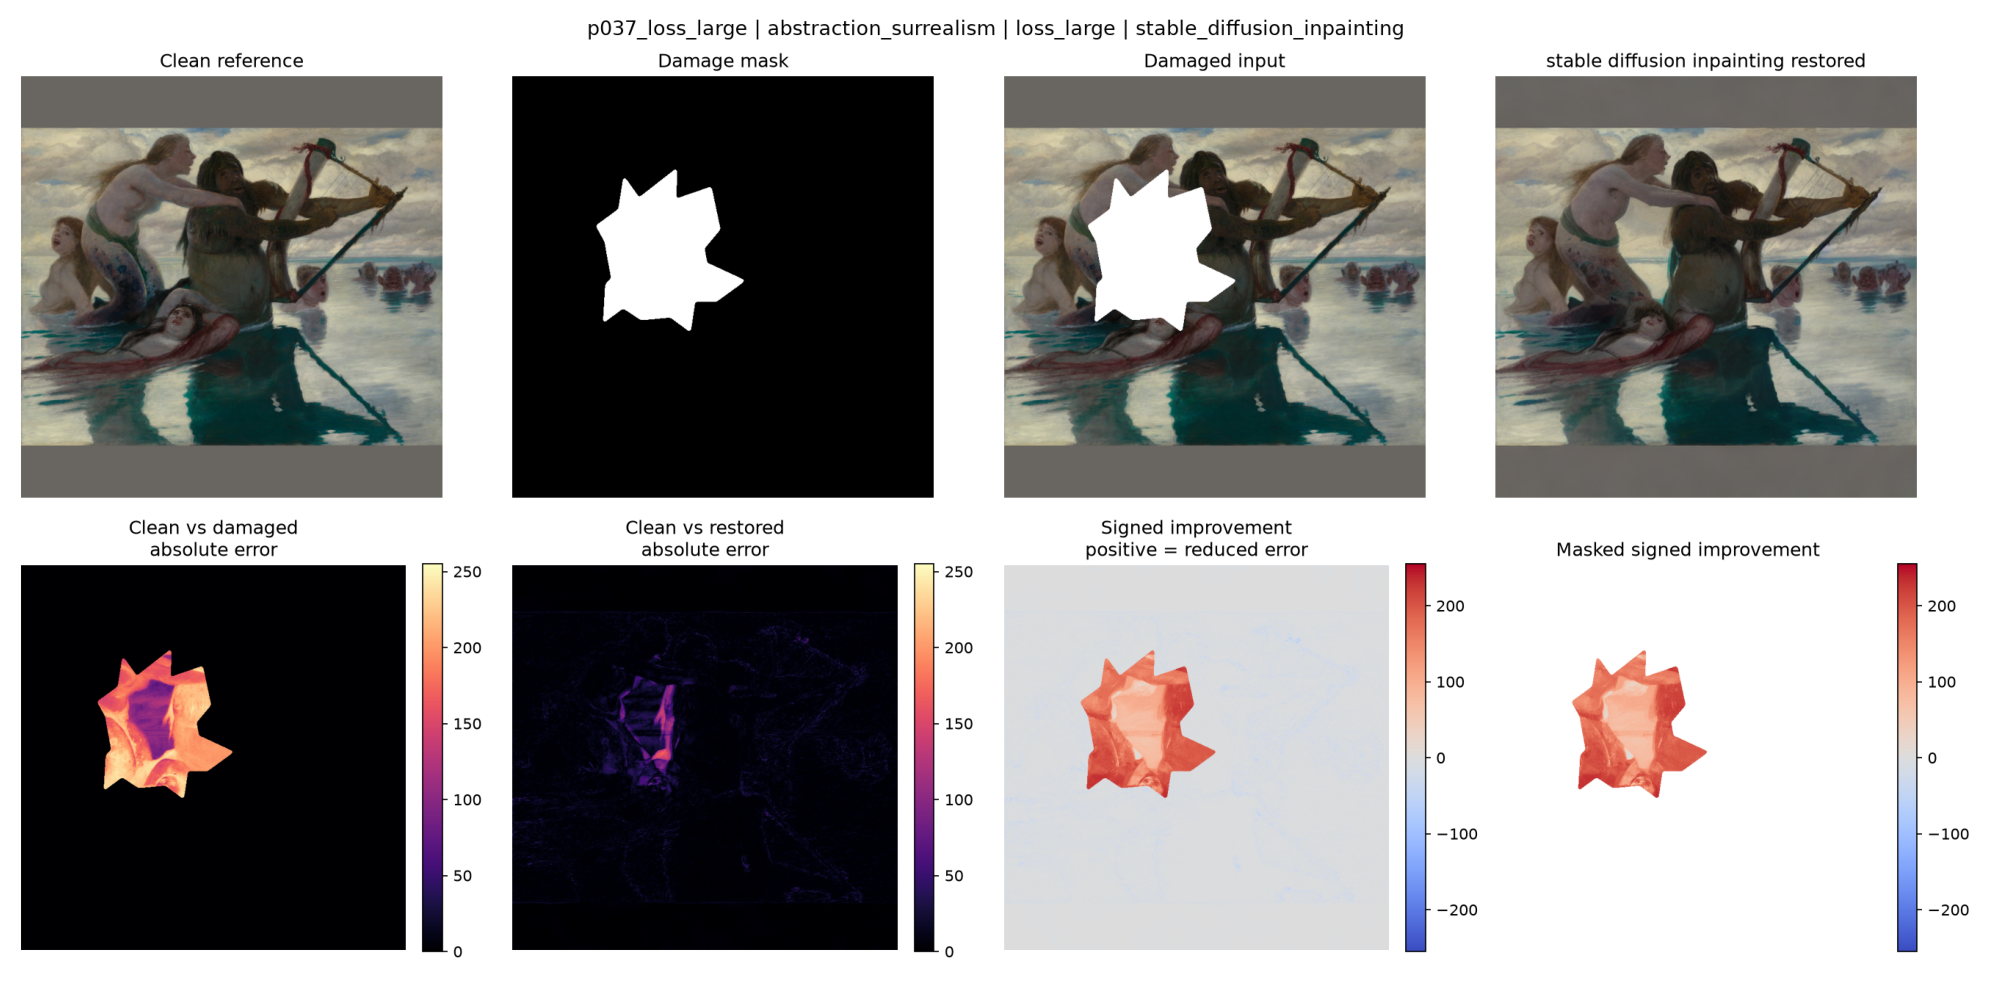

Displaying p032_loss_large | abstraction_surrealism | loss_large | classical_metric_disagreement


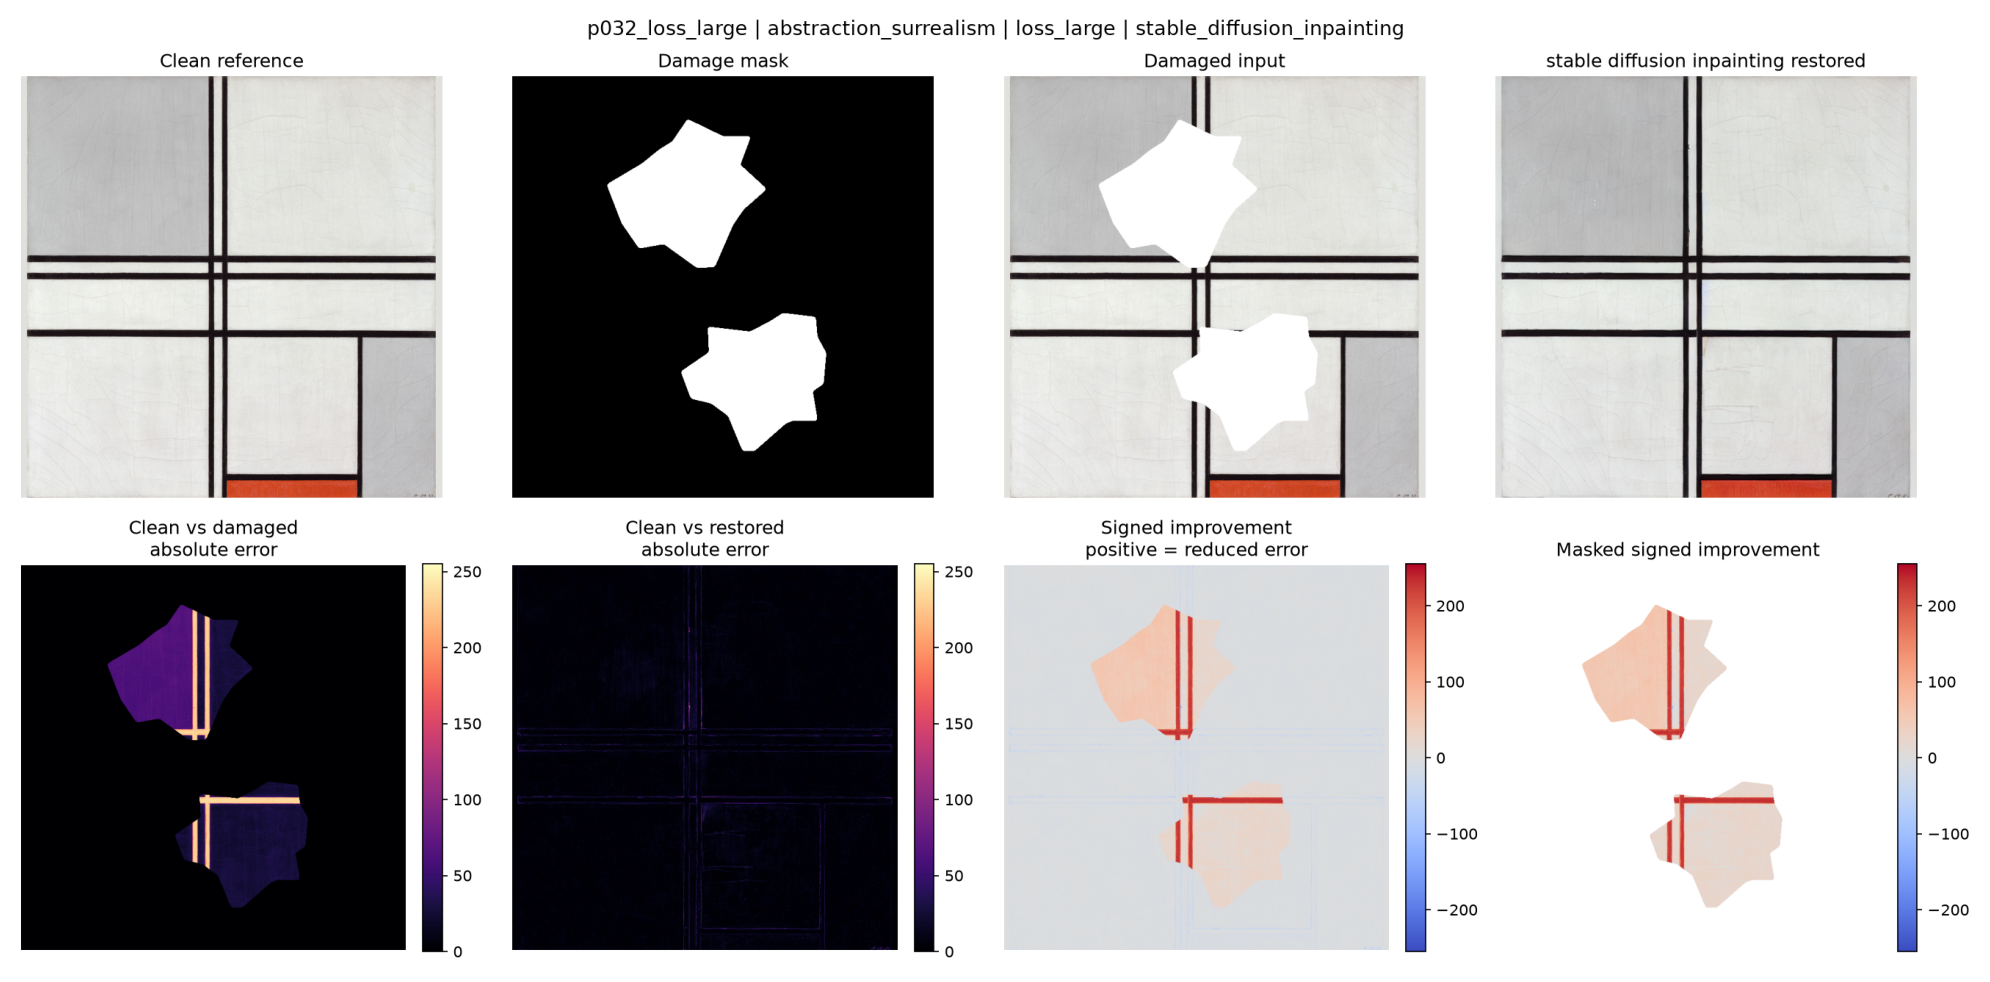

Displaying p036_loss_large | abstraction_surrealism | loss_large | classical_metric_disagreement; worst_masked_region_mse_improvement


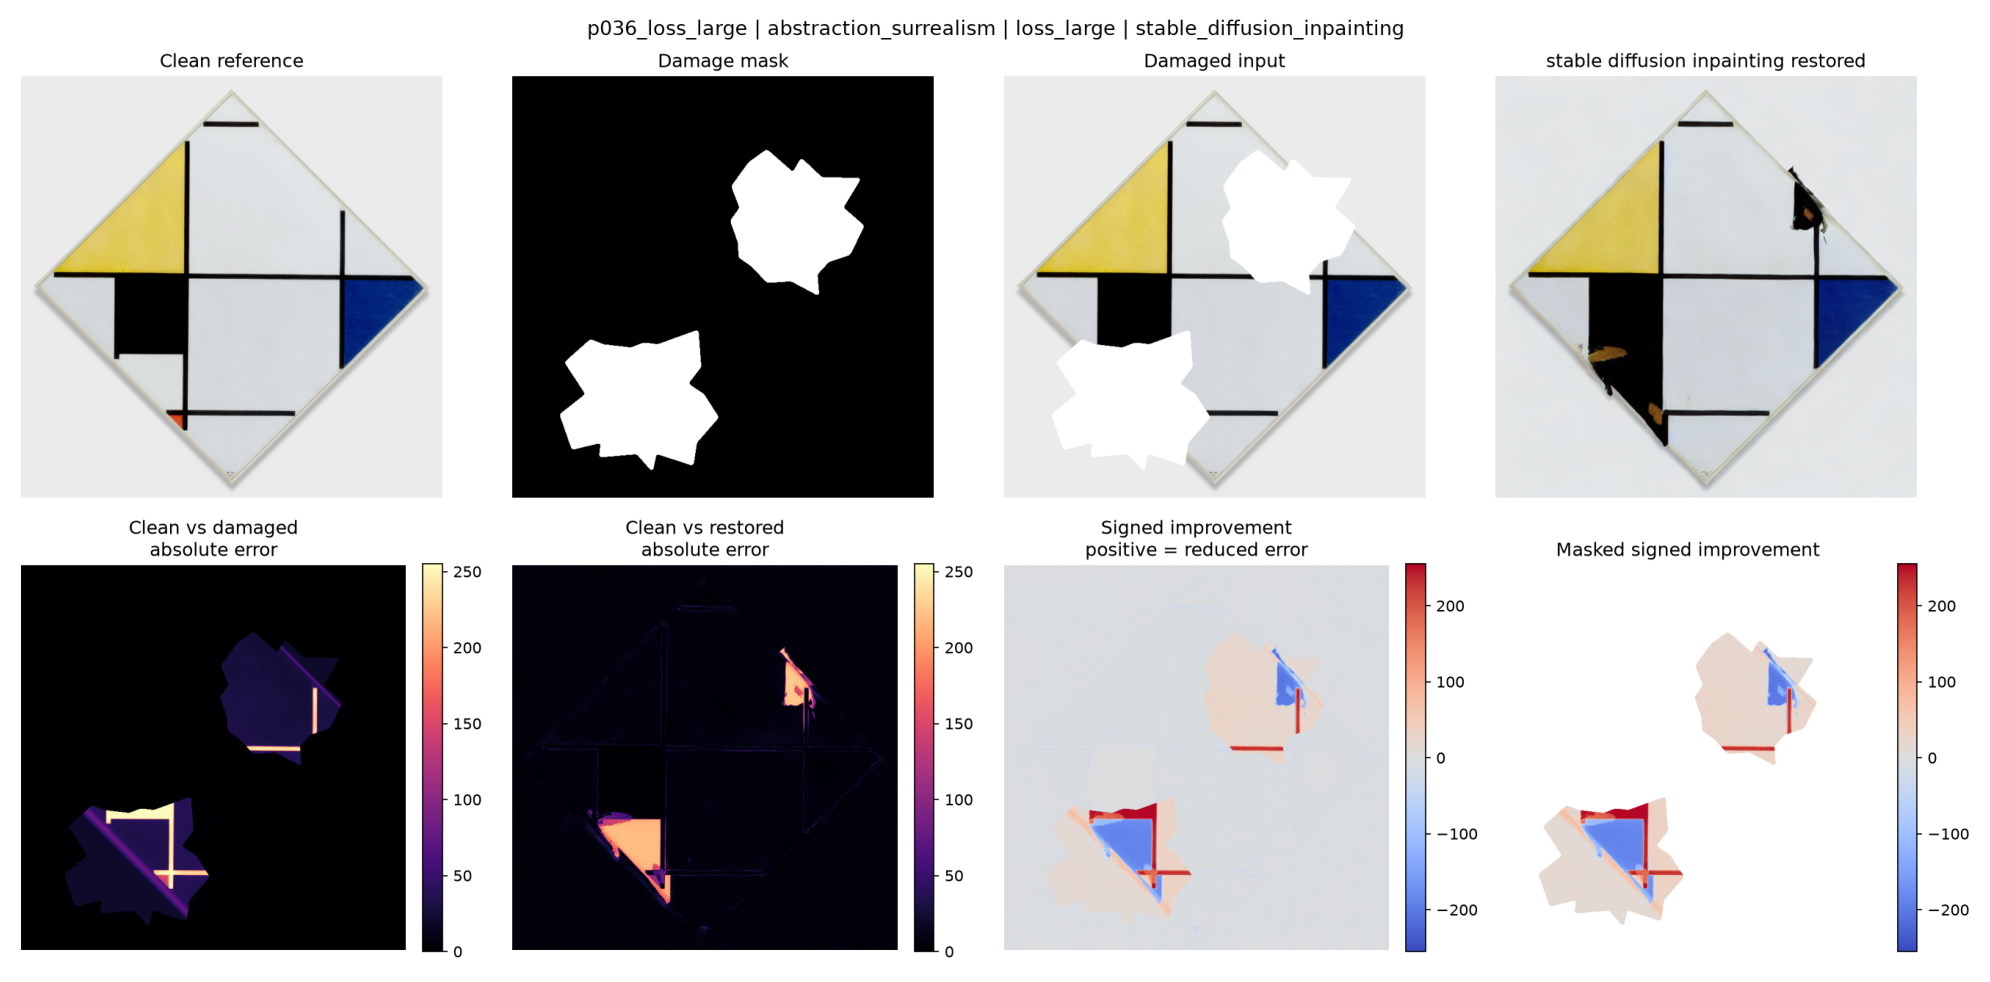

Displaying p035_loss_small | abstraction_surrealism | loss_small | median_representative_masked_region_mse_improvement


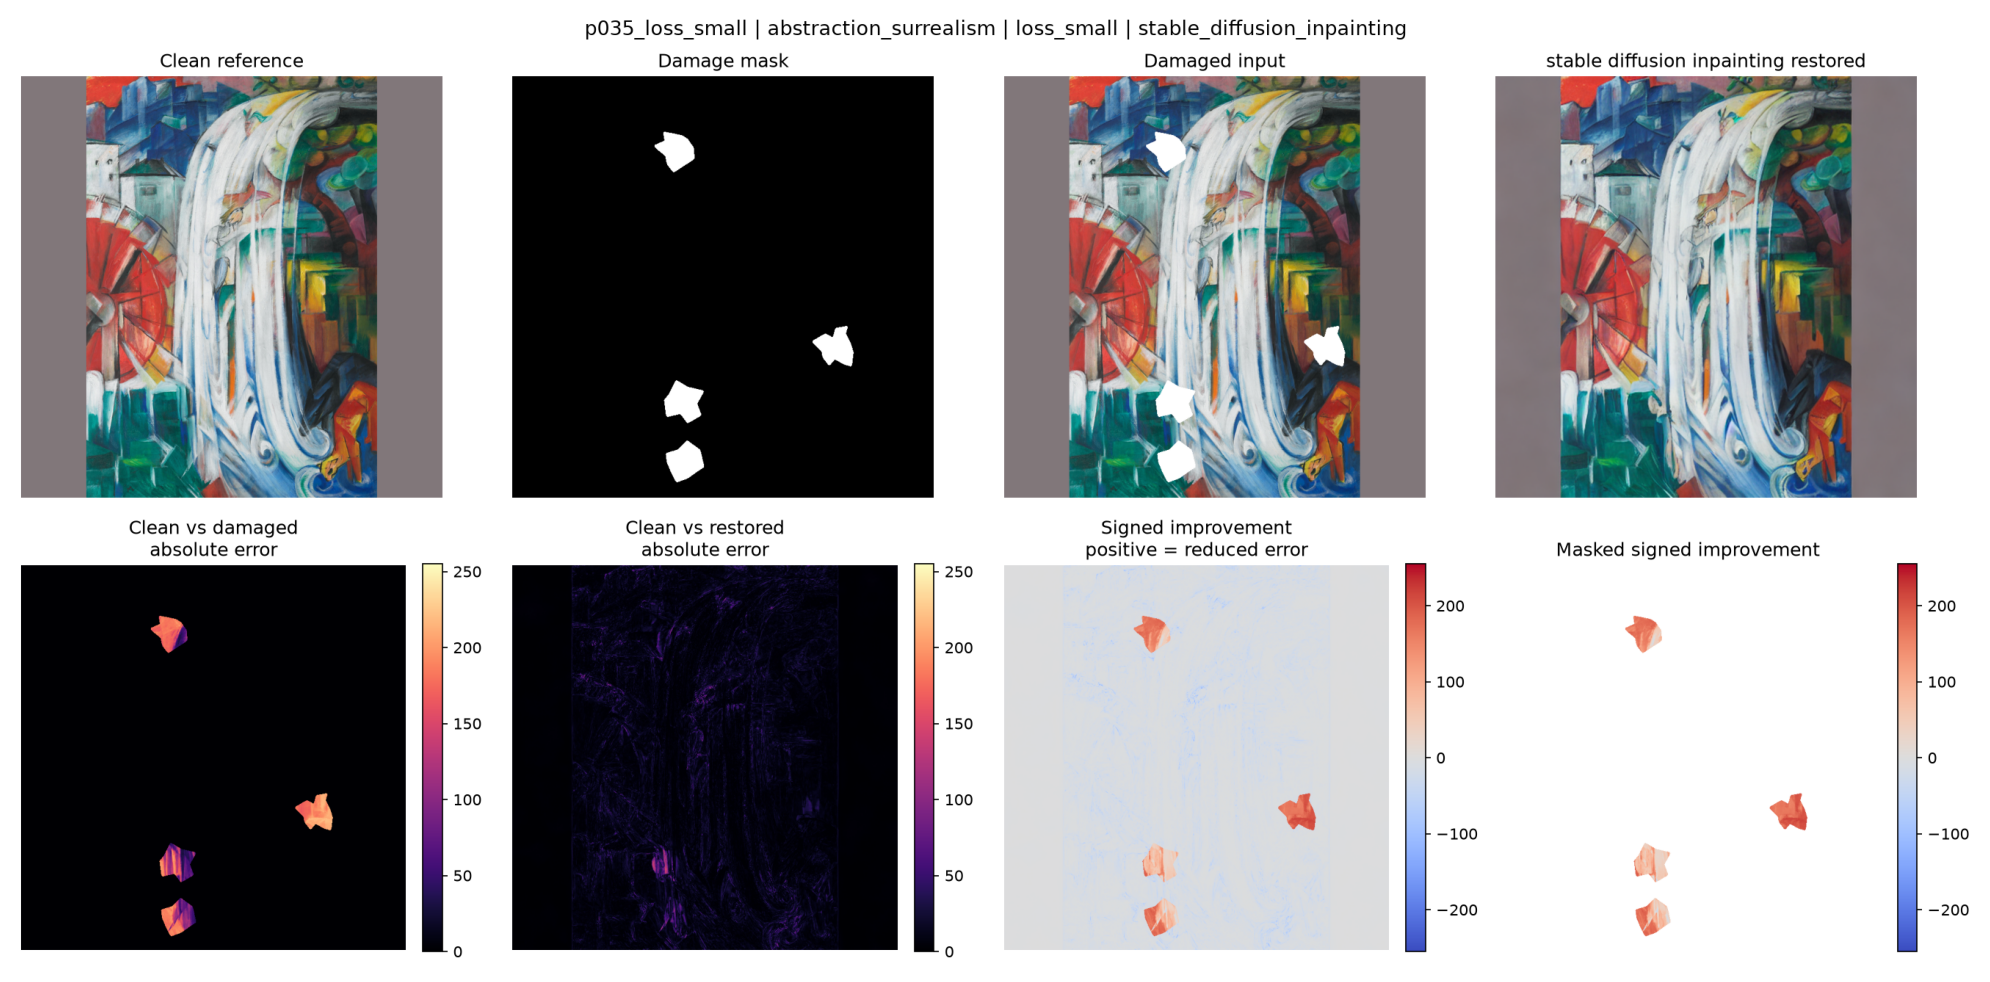

Displaying p032_scratch_thin | abstraction_surrealism | scratch_thin | worst_masked_region_mse_improvement


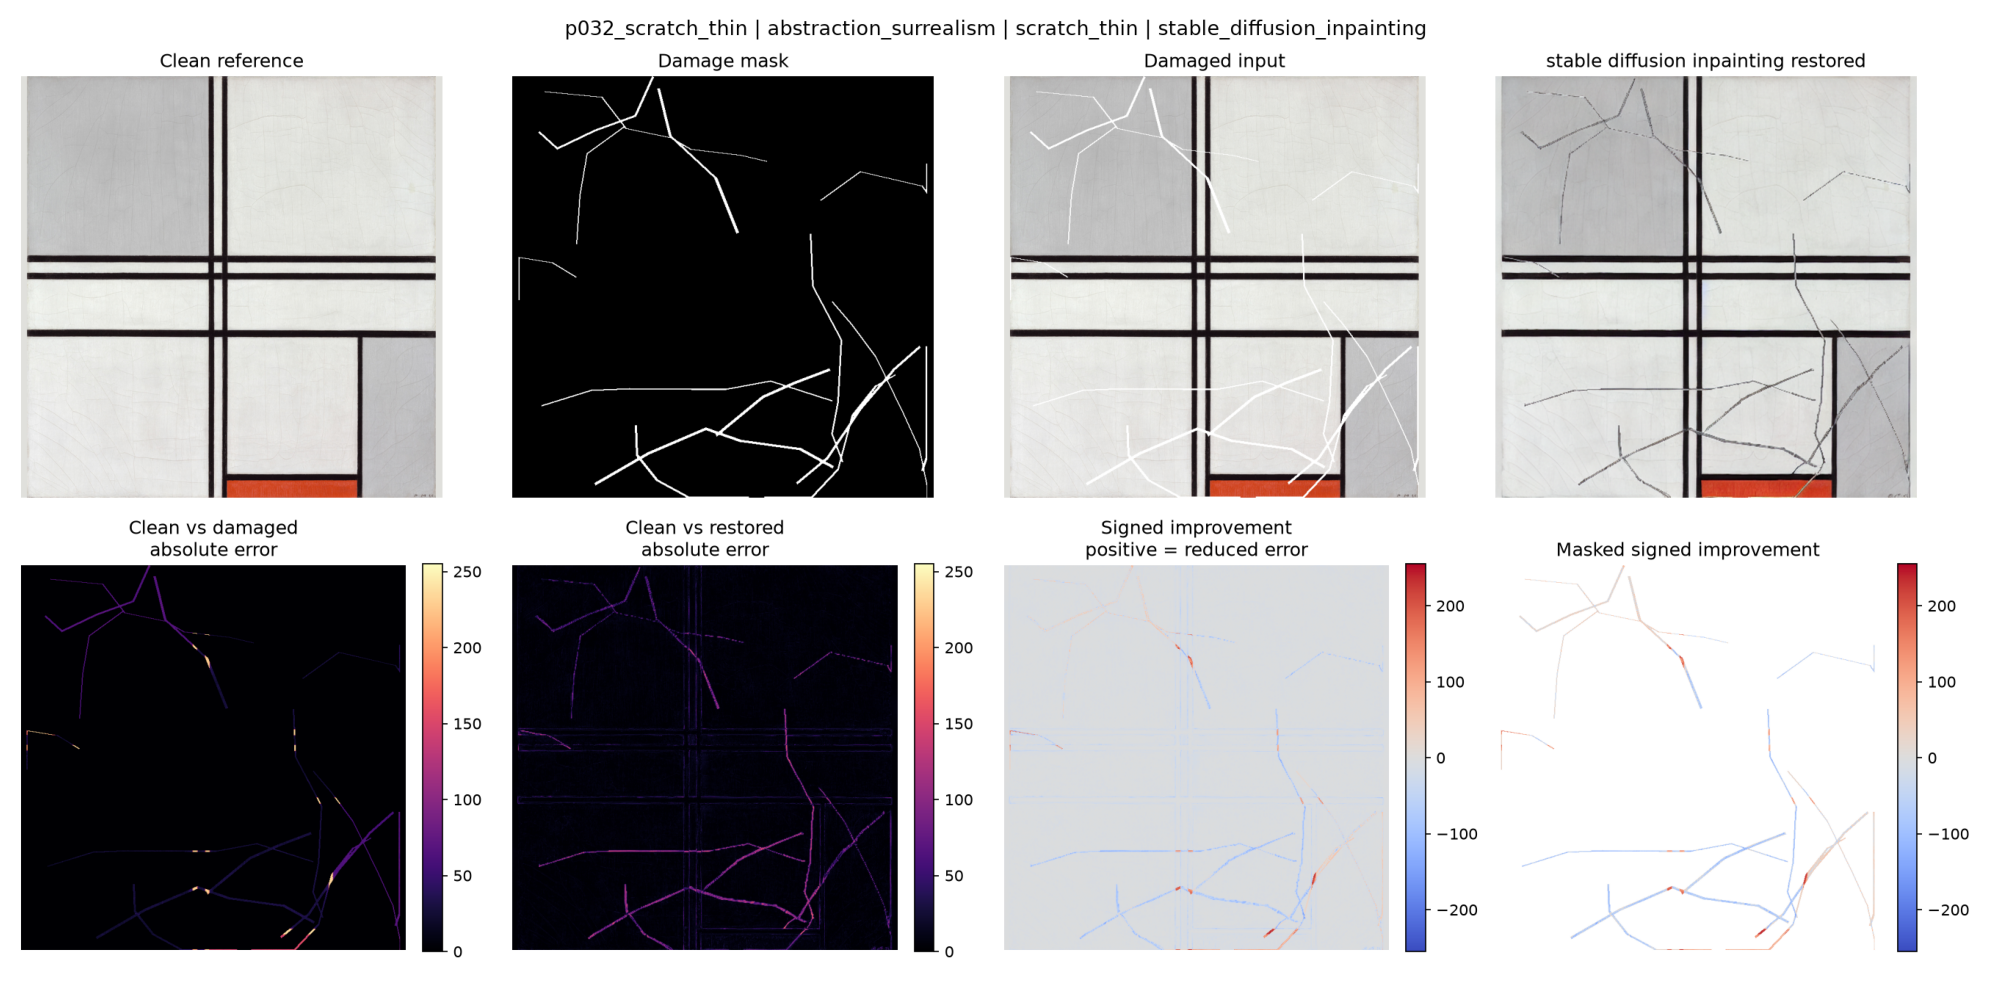

In [18]:
def display_error_map_figure(path_value: str | Path) -> None:
    figure_path = Path(path_value)

    if not figure_path.exists():
        raise FileNotFoundError(f"Missing error-map figure: {figure_path}")

    image = Image.open(figure_path).convert("RGB")

    plt.figure(figsize=(20, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


figure_path_columns = [
    column
    for column in error_map_manifest_saved_df.columns
    if "figure" in column.lower() and "path" in column.lower()
]

if not figure_path_columns:
    raise ValueError("No figure path column found in saved error-map manifest.")

figure_path_column = figure_path_columns[0]

sample_display_df = (
    error_map_manifest_saved_df
    .merge(
        error_map_visual_cases_saved_df[
            ["case_id", "selection_reason", "mse_improvement", "psnr_improvement", "ssim_improvement"]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(["selection_reason", "category", "mask_type", "case_id"])
    .groupby("selection_reason", dropna=False)
    .head(1)
    .copy()
)

print("Displaying sample Stable Diffusion error-map figures:", len(sample_display_df))

display(
    sample_display_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            figure_path_column,
        ]
    ]
)

for _, row in sample_display_df.iterrows():
    print(
        f"Displaying {row['case_id']} | "
        f"{row['category']} | {row['mask_type']} | "
        f"{row['selection_reason']}"
    )
    display_error_map_figure(row[figure_path_column])

In [19]:
expected_error_map_files = [
    error_map_manifest_path,
    error_map_summary_by_mask_type_path,
    error_map_summary_by_category_path,
    error_map_visual_cases_path,
]

for output_file in expected_error_map_files:
    if not output_file.exists():
        raise FileNotFoundError(
            f"Missing expected Stable Diffusion error-map output: {output_file}"
        )

saved_manifest_df = pd.read_csv(error_map_manifest_path)
saved_visual_cases_df = pd.read_csv(error_map_visual_cases_path)
saved_summary_by_mask_type_df = pd.read_csv(error_map_summary_by_mask_type_path)
saved_summary_by_category_df = pd.read_csv(error_map_summary_by_category_path)

if len(saved_manifest_df) != len(saved_visual_cases_df):
    raise ValueError(
        f"Manifest and visual case row mismatch: "
        f"manifest={len(saved_manifest_df)}, visual_cases={len(saved_visual_cases_df)}."
    )

if len(saved_visual_cases_df) == 0:
    raise ValueError("Stable Diffusion error-map visual case selection is empty.")

if len(saved_summary_by_mask_type_df) == 0:
    raise ValueError("Stable Diffusion error-map mask-type summary is empty.")

if len(saved_summary_by_category_df) == 0:
    raise ValueError("Stable Diffusion error-map category summary is empty.")

expected_selection_reasons = [
    "best_masked_region_mse_improvement",
    "worst_masked_region_mse_improvement",
    "median_representative_masked_region_mse_improvement",
    "classical_metric_disagreement",
    "category_mask_representative_best_mse_improvement",
]

selection_reason_text = " ".join(
    saved_visual_cases_df["selection_reason"].fillna("").astype(str).tolist()
)

missing_selection_reasons = [
    reason
    for reason in expected_selection_reasons
    if reason not in selection_reason_text
]

if missing_selection_reasons:
    raise ValueError(
        f"Missing expected selection reasons: {missing_selection_reasons}"
    )

required_visual_case_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "selection_reason",
    "mse_improvement",
    "mae_improvement",
    "psnr_improvement",
    "ssim_improvement",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_visual_case_columns = [
    column for column in required_visual_case_columns
    if column not in saved_visual_cases_df.columns
]

if missing_visual_case_columns:
    raise ValueError(
        f"Saved visual cases missing columns: {missing_visual_case_columns}"
    )

required_manifest_columns = [
    "case_id",
    "painting_id",
    "category",
    "mask_type",
]

missing_manifest_columns = [
    column for column in required_manifest_columns
    if column not in saved_manifest_df.columns
]

if missing_manifest_columns:
    raise ValueError(
        f"Saved error-map manifest missing columns: {missing_manifest_columns}"
    )

figure_path_columns = [
    column
    for column in saved_manifest_df.columns
    if "figure" in column.lower() and "path" in column.lower()
]

if not figure_path_columns:
    print("Manifest columns:")
    print(list(saved_manifest_df.columns))
    raise ValueError("No figure path column found in saved error-map manifest.")

for figure_path_column in figure_path_columns:
    missing_figures = [
        path
        for path in saved_manifest_df[figure_path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(figure_path_column, "missing figures:", len(missing_figures))

    if missing_figures:
        raise FileNotFoundError(
            f"Missing error-map figures in {figure_path_column!r}: "
            f"{missing_figures[:10]}"
        )

print("Saved error-map manifest rows:", len(saved_manifest_df))
print("Saved selected visual case rows:", len(saved_visual_cases_df))
print("Stable Diffusion error-map final gates passed.")

figure_path missing figures: 0
Saved error-map manifest rows: 53
Saved selected visual case rows: 53
Stable Diffusion error-map final gates passed.


## Notebook 20 summary

This notebook generated spatial difference/error-map diagnostics for the Stable Diffusion Inpainting baseline.

The diagnostic case selection followed a fixed policy:

- best cases by masked-region MSE improvement,
- worst cases by masked-region MSE improvement,
- median representative cases,
- classical metric-disagreement cases,
- category/mask representative cases.

Main outputs:

- `outputs/metrics/error_map_manifest_stable_diffusion_50.csv`
- `outputs/metrics/error_map_summary_by_mask_type_stable_diffusion_50.csv`
- `outputs/metrics/error_map_summary_by_category_stable_diffusion_50.csv`
- `outputs/metrics/stable_diffusion_error_map_visual_cases_50.csv`
- `outputs/figures/error_maps/stable_diffusion_inpainting/`

The generated figures compare the clean reference, mask, damaged input, Stable Diffusion restoration, damaged error, restored error, signed improvement, and masked signed improvement.

This stage completes the spatial diagnostic layer for Stable Diffusion and prepares the model for perceptual LPIPS evaluation.